## Aerodynamic Shape Optimization

### Minimum Induced Drag (Elliptical Wing)

Let's do some aerodynamic shape optimization, using a classic problem:

Find the wing shape that minimizes induced drag, with the following assumptions:

* A fixed lift
* A fixed wing area
* A fixed wing span
* An untwisted, uncambered, thin, planar wing
* Inviscid, incompressible, irrotational, steady flow

The answer, as any good introductory aerodynamics textbook will teach, is a wing with an elliptical lift distribution. For an untwisted wing (in small angle approximation), this corresponds to an elliptical chord distribution.

Let's pose the problem in AeroSandbox, using the `VortexLatticeMethod` flow solver.

In [1]:
import aerosandbox as asb
import aerosandbox.numpy as np
import matplotlib.pyplot as plt

In [2]:
opti = asb.Opti()  # Initialize an optimization environment.

N = 60  # Number of chord sections to optimize

# The y-locations (i.e. span locations) of each section. Note that the span is fixed.
section_y = np.linspace(0, 2.785, N)
# Using `linspace` gives us evenly spaced sections along the span.

## Définition dérive

### Variables

In [3]:
# Linear twist distribution parameterization
twist_root = opti.variable(init_guess=5)  # Twist at root (y=0) in degrees
twist_slope = opti.variable(init_guess=-1)  # Linear gradient (deg per unit span)

# Compute twists as a linear function of spanwise position
twists = twist_root + twist_slope * section_y
chord = opti.variable(init_guess=1, lower_bound=0.1, upper_bound=5)  # Chord length (constant across span)

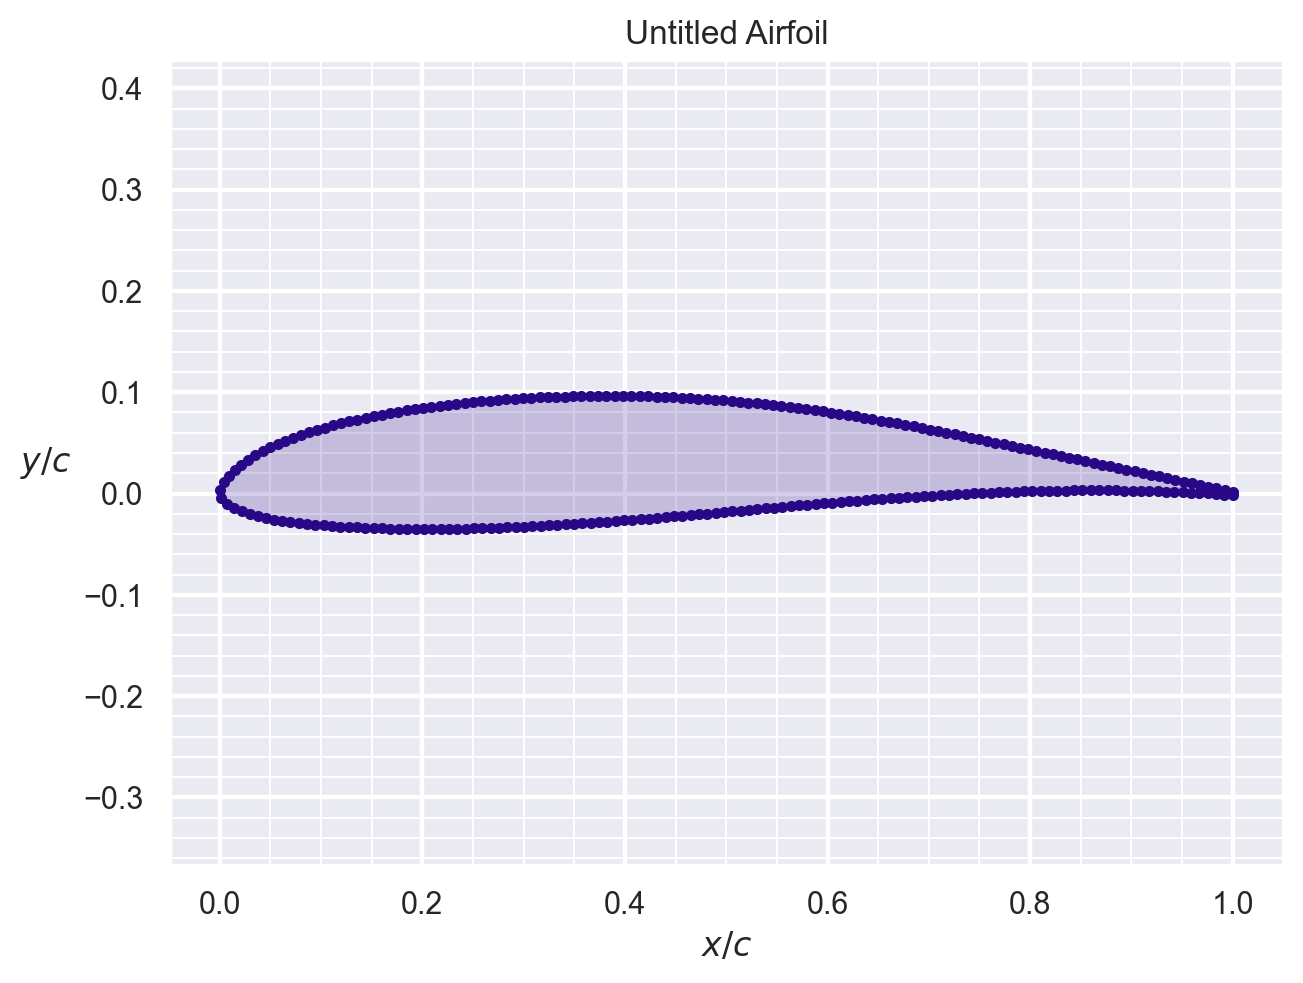

In [4]:
section = asb.Airfoil(coordinates= r'C:\Users\antoine.vittet\Desktop\MC2_60_6101_1.dat')
section.draw()

In [12]:
section.generate_polars(
    xfoil_kwargs={'xfoil_command': r'C:\Users\antoine.vittet\Documents\bdToolbox\soft\xfoil.exe'}
)

Running XFoil to generate polars for Airfoil 'Untitled'::   0%|          | 0/12 [00:00<?, ?it/s]c:\Users\antoine.vittet\Documents\bdToolbox\.venv\lib\site-packages\aerosandbox\aerodynamics\aero_2D\xfoil.py:668: UserWarning: XFoil run timed out!
If this was not expected, try increasing the `timeout` parameter
when you create this AeroSandbox XFoil instance.
  output = self._run_xfoil(
Running XFoil to generate polars for Airfoil 'Untitled':: 100%|██████████| 12/12 [01:09<00:00,  5.81s/it]


In [5]:
wing = asb.Wing(
    symmetric=True,
    xsecs=[
        asb.WingXSec(
            xyz_le=[
                0,
                section_y[i],  # Our (known) span locations for each section.
                0,
            ],
            chord=chord,
            twist=twists[i], #0 OR twists[i]
            airfoil = section
        )
        for i in range(N)
    ],
)

airplane = asb.Airplane(  # Make an airplane object containing only this wing.
    wings=[wing]
)

In [7]:
from pyvista.trame.jupyter import launch_server
await launch_server().ready
airplane.draw() # doesn't work if we use `twists[i]` as the twist value, since `twists` is an optimization variable, not a numeric value. 

TypeError: object of type 'MX' has no len()

## VLM method setup

In [ ]:
# alpha = opti.variable(init_guess=np.radians(5), lower_bound= 0, upper_bound=15)  # Angle of attack, also to be optimized.
alpha = 0 # We could chose to set alpha to a different value for example to the typical leeway angle at certain navigation case

op_point = asb.OperatingPoint(
    velocity=1,  # Some fixed velocity; doesn't matter since we're working nondimensionally.
    alpha=alpha,
)

vlm = asb.VortexLatticeMethod(
    airplane=airplane,
    op_point=op_point,
    spanwise_resolution=1,
    chordwise_resolution=8,
)

aero = vlm.run()

CD_friction = 0.0021 * wing.area() # coeff provenant de simus xfoil

## Contraintes

In [7]:
opti.subject_to(
    [  # Constraints for linear twist distribution
        twist_root > 5,  # Root twist lower bound
        twist_root < 20,  # Root twist upper bound
        twist_root + twist_slope * section_y[-1] > -20,  # Ensure tip twist > 0
        twist_root + twist_slope * section_y[-1] < 20,  # Ensure tip twist < 20
        twist_slope <= 0,  # Negative slope for washout (decreasing twist)
        aero["CL"] * wing.area() == 2.785,  # Lift coefficient constraint
        aero["CD"] > 0,  # Drag must be positive (trivial, but helps the optimizer)
    ]
)

[MX(fabs(opti0_lam_g_3)),
 MX(fabs(opti0_lam_g_4)),
 MX(fabs(opti0_lam_g_5)),
 MX(fabs(opti0_lam_g_6)),
 MX(fabs(opti0_lam_g_7)),
 MX(fabs(opti0_lam_g_8)),
 MX(fabs(opti0_lam_g_9))]

## Résolution de l'optimisation

In [ ]:
# NBVAL_SKIP
# (This tells our unit tests to skip this cell, as it's a bit wasteful to run on every commit.)

# opti.minimize(aero["CD"])

L_over_D = aero["CL"] / (aero["CD"] + CD_friction)

opti.minimize(-L_over_D)

sol = opti.solve()

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        3
Number of nonzeros in inequality constraint Jacobian.:       12
Number of nonzeros in Lagrangian Hessian.............:        6

Total number of variables............................:        3
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality constraints...............:        8
        inequality constraints with only lower bounds:        4
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        4

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -3.1779029e+01 3.26e-01 2.13e-01   0.0 0.00e+00    -  0.00e+00 0.00e+00 

Finally, we add our lift constraint, set the optimization objective to minimize drag, and solve.

In [41]:
twist_current = opti.debug.value(twists)  # Gets the last value of x before the solver failed
print(f"twist_current = {twist_current}")
# chord_current = opti.debug.value(chords)
# print(f"chord_current = {chord_current}")
alpha_current = opti.debug.value(alpha)
print(f"alpha_current = {alpha_current:.3f} deg")
cl_current = opti.debug.value(aero["CL"])
cd_current = opti.debug.value(aero["CD"])
print(f"CL = {cl_current:.3f}, CD = {cd_current:.4f}, L/D = {cl_current/cd_current:.1f}")
S_current = opti.debug.value(wing.area())
print(f"Wing area = {S_current:.3f} m^2")
S_Cl_current = opti.debug.value(wing.area() * aero["CL"])
print(f"S * CL = {S_Cl_current:.3f}")
chord_current = opti.debug.value(chord)
print(f"Chord = {chord_current:.3f} m")

twist_current = [4.65257264 4.6045302  4.55648775 4.50844531 4.46040286 4.41236042
 4.36431798 4.31627553 4.26823309 4.22019065 4.1721482  4.12410576
 4.07606331 4.02802087 3.97997843 3.93193598 3.88389354 3.83585109
 3.78780865 3.73976621 3.69172376 3.64368132 3.59563887 3.54759643
 3.49955399 3.45151154 3.4034691  3.35542666 3.30738421 3.25934177
 3.21129932 3.16325688 3.11521444 3.06717199 3.01912955 2.9710871
 2.92304466 2.87500222 2.82695977 2.77891733 2.73087488 2.68283244
 2.63479    2.58674755 2.53870511 2.49066266 2.44262022 2.39457778
 2.34653533 2.29849289 2.25045045 2.202408   2.15436556 2.10632311
 2.05828067 2.01023823 1.96219578 1.91415334 1.86611089 1.81806845]
alpha_current = 0.000 deg
CL = 0.542, CD = 0.0153, L/D = 35.4
Wing area = 5.134 m^2
S * CL = 2.785
Chord = 0.922 m


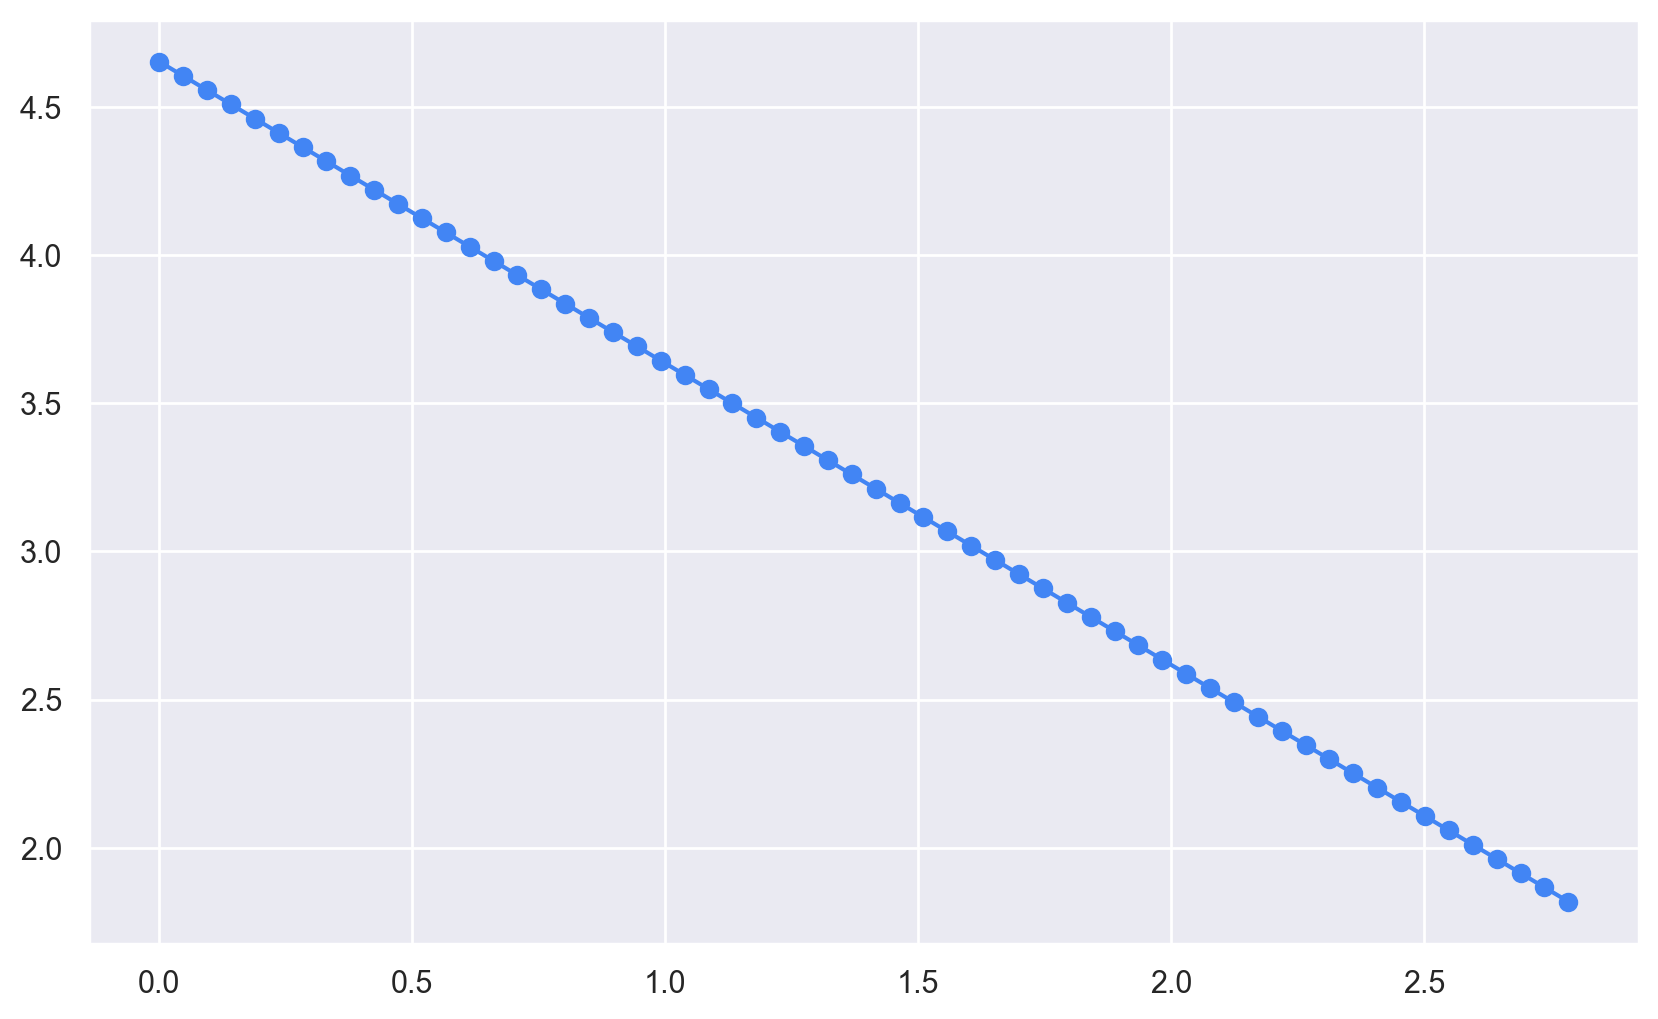

In [42]:
plt.figure(figsize=(10, 6))
plt.plot(section_y, twist_current, marker="o")

Let's visualize our solution.

The following command does an in-place substitution of our VLM object, recursively evaluating all its fields from abstract values to concrete ones (i.e., NumPy arrays) at our solution, using our `sol` object.

In [9]:
# NBVAL_SKIP

vlm = sol(vlm)

In [10]:
# NBVAL_SKIP
from pyvista.trame.jupyter import launch_server
await launch_server().ready

vlm.draw()

Widget(value='<iframe src="http://localhost:53970/index.html?ui=P_0x230d9e64190_0&reconnect=auto" class="pyvis…

In [15]:
# chord_res = sol(chords)
# print(f"Chord values : {chord_res}")
twist = sol(twists)
print(f"Twist distribution (deg) : {twist}")
twist_slope_res = sol(twist_slope)
print(f"Twist slope (deg/unit span) : {twist_slope_res:.3f}")
root_twist_res = sol(twist_root)
print(f"Root twist (deg) : {root_twist_res:.3f}")
alpha_res = sol(alpha)
print(f"Angle of attack : {alpha_res:.3f} deg")
cl_res = sol(aero["CL"])
print(f"CL = {cl_res:.6f}")
cd_res = sol(aero["CD"])
print(f"CD = {cd_res:.6f}")
chord_res = sol(chord)
print(f"Chord = {chord_res:.3f} m")
surface_area_res = sol(wing.area())
print(f"Wing area = {surface_area_res:.3f} m^2")
S_Cl_res = sol(wing.area() * aero["CL"])
print(f"S * CL = {S_Cl_res:.3f}")

Twist distribution (deg) : [5.01397223 4.95000787 4.88604351 4.82207915 4.75811479 4.69415043
 4.63018607 4.5662217  4.50225734 4.43829298 4.37432862 4.31036426
 4.2463999  4.18243554 4.11847117 4.05450681 3.99054245 3.92657809
 3.86261373 3.79864937 3.73468501 3.67072064 3.60675628 3.54279192
 3.47882756 3.4148632  3.35089884 3.28693448 3.22297011 3.15900575
 3.09504139 3.03107703 2.96711267 2.90314831 2.83918395 2.77521958
 2.71125522 2.64729086 2.5833265  2.51936214 2.45539778 2.39143342
 2.32746905 2.26350469 2.19954033 2.13557597 2.07161161 2.00764725
 1.94368289 1.87971852 1.81575416 1.7517898  1.68782544 1.62386108
 1.55989672 1.49593236 1.43196799 1.36800363 1.30403927 1.24007491]
Twist slope (deg/unit span) : -1.355
Root twist (deg) : 5.014
Angle of attack : 0.000 deg
CL = 0.535291
CD = 0.015099
Chord = 0.934 m
Wing area = 5.203 m^2
S * CL = 2.785


Text(0.5, 1.0, 'Optimized Twist Distribution')

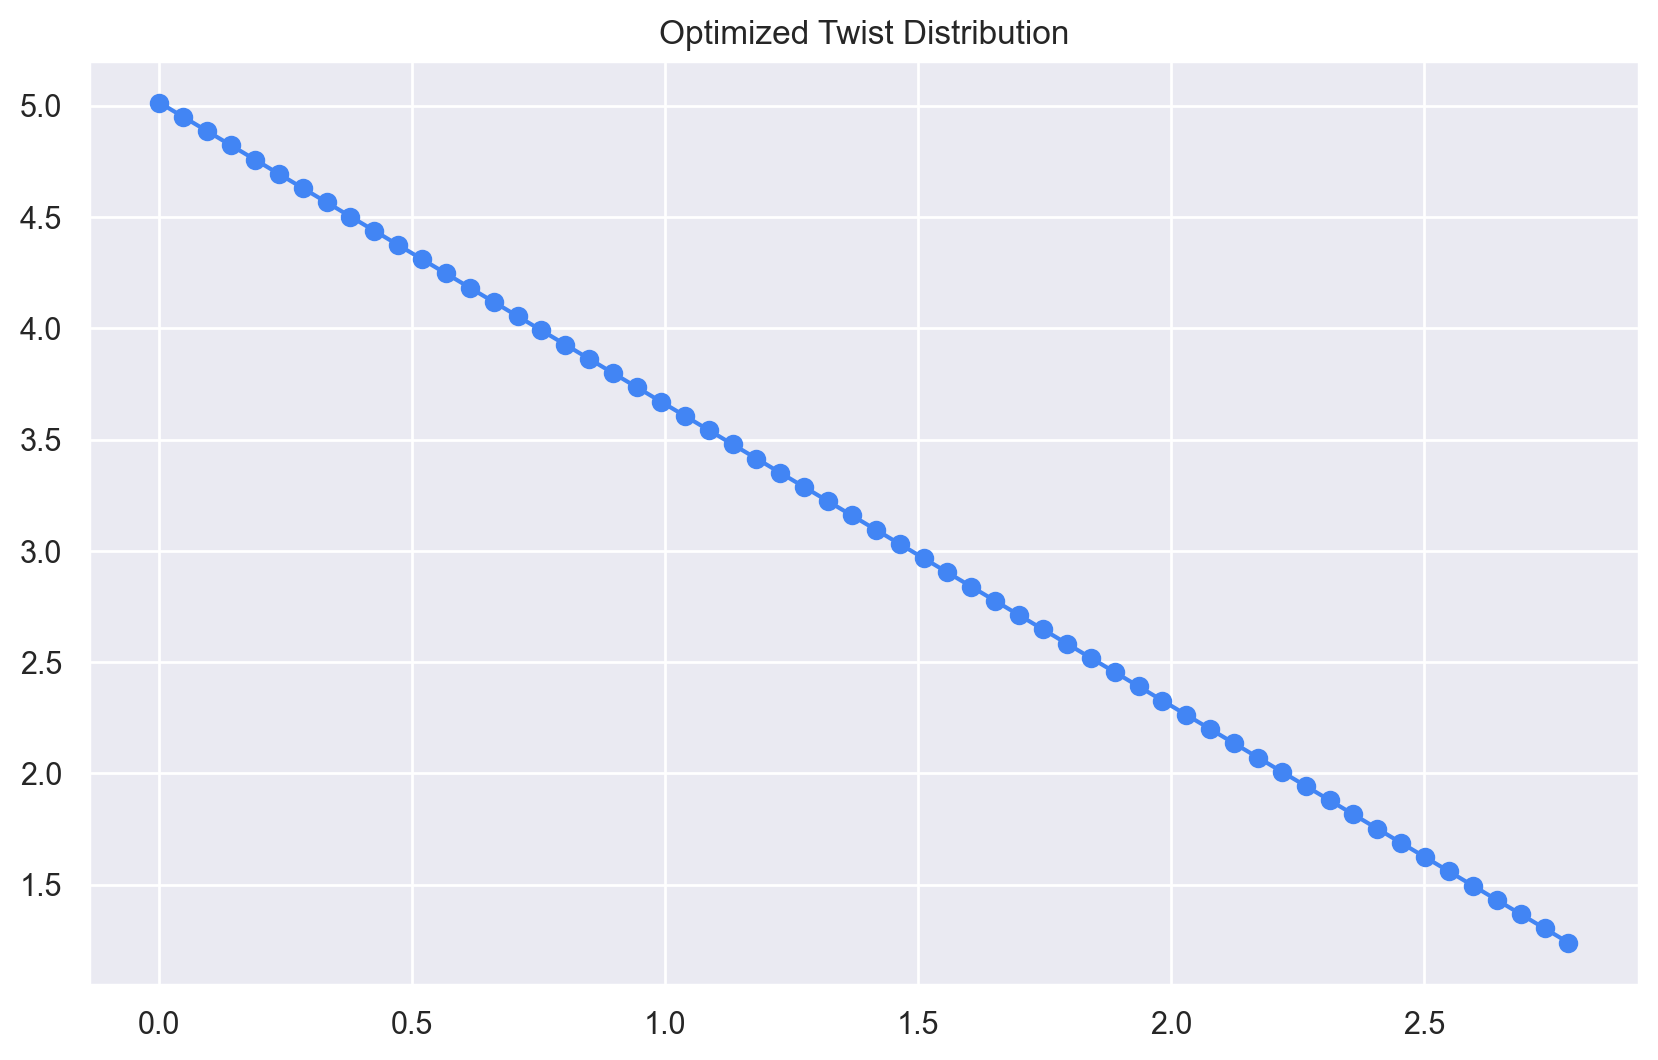

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(section_y, twist, marker="o")
plt.title("Optimized Twist Distribution")

Looking at our optimized solution, we can compare it to our known analytic solution (an elliptical lift distribution).

NameError: name 'chords' is not defined

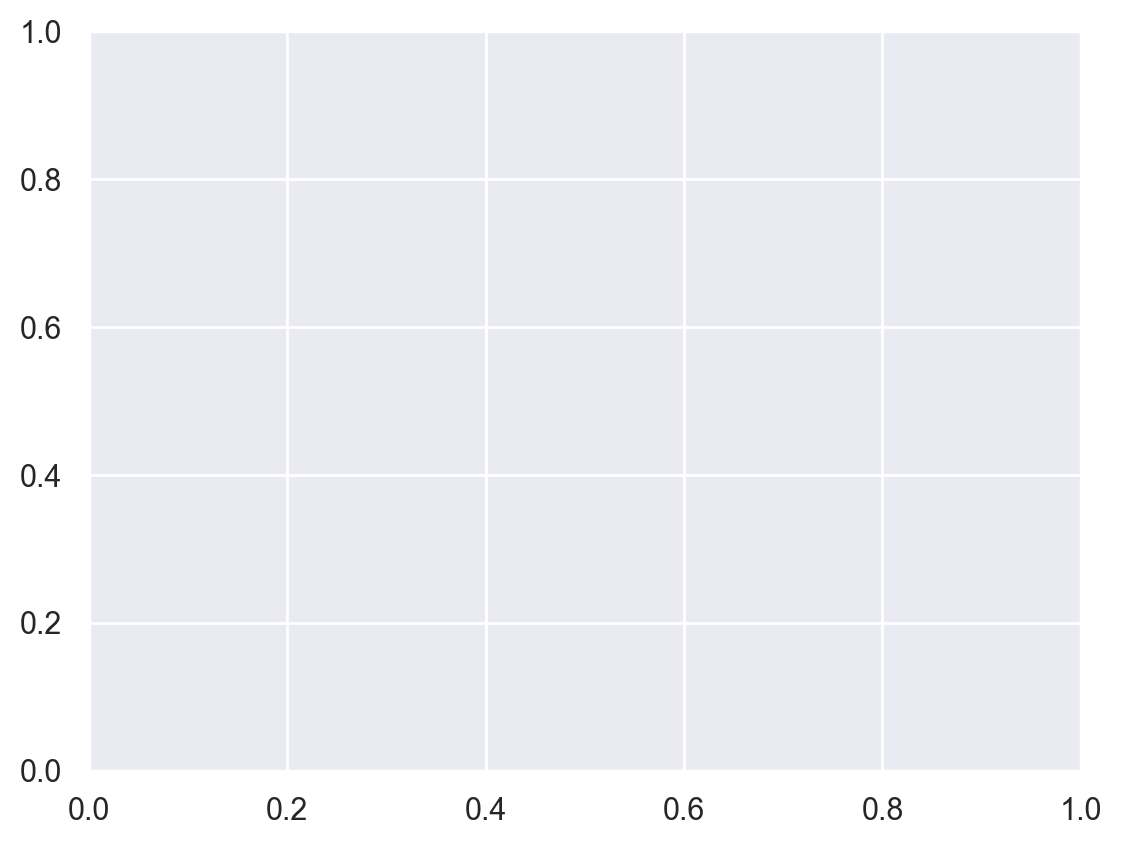

In [ ]:
# NBVAL_SKIP

import matplotlib.pyplot as plt
import aerosandbox.tools.pretty_plots as p

fig, ax = plt.subplots()
plt.plot(
    section_y,
    sol(chords),
    ".-",
    label="AeroSandbox VLM Result",
    zorder=4,
)
y_plot = np.linspace(0, 1, 500)
plt.plot(
    y_plot,
    (1 - y_plot**2) ** 0.5 * 4 / np.pi * 0.125,
    label="Elliptic Distribution",
)
p.show_plot(
    "AeroSandbox Drag Optimization using VortexLatticeMethod", "Span [m]", "Chord [m]"
)

Slight differences arise due to numerical discretization, but it's convergent to the right answer. We can also check the objective function (the induced drag at the minimum):

In [ ]:
# NBVAL_SKIP

AR = 2**2 / 0.25
CL = 1

CDi_theory = CL**2 / (np.pi * AR)
CDi_computed = sol(aero["CD"])
print(f"CDi (theory)   : {CDi_theory:.4f}")
print(f"CDi (computed) : {CDi_computed:.4f}")

CDi (theory)   : 0.0199
CDi (computed) : 0.0188


Essentially matching theory. Both theory and computation are expected to have slight errors compared to the exact potential flow solution:

* The theory side has small errors due to small-angle approximations and simplification of 3D chordwise effects near the tips
* The computational side has small errors due to numerical discretization.

(Both methods neglect thickness effects, too.)